# Python for AI — Class 17
### EDA Project: explore a real dataset (Month 1 Milestone)

**EDA** means **Exploratory Data Analysis**. Before we build any AI model, we must **understand the data**:
What is in it? What is missing? What is strange? What is related to what?

Today we use everything from Month 1: Python, files, NumPy, Pandas and charts.

**Our dataset:** the real **Titanic** passenger list. The Titanic was a big ship. It sank in 1912. We have data for 891 passengers.

**Our big question:** *What kind of passengers survived?*

At the end, you will do the same steps on a dataset **you choose**. That is your **Month 1 portfolio project**.

## How we will learn today

Every topic has the same 4 steps:

| Step | What happens |
|------|--------------|
| **CONCEPT** | The teacher explains the idea. Short points. |
| **EXAMPLE** | The teacher types the code. **You type it too** and run it. |
| **QUICK CHECK** | You solve a small task alone. |
| **SOLUTION** | We check the answer together. The solutions are in a separate file. |

**Tip:** Run a cell with `Shift + Enter`.

# Hour 1: Load, Inspect and Plan

## CONCEPT: The 5 steps of EDA

| Step | What we do | Tools |
|------|------------|-------|
| 1. **Load** | read the file | `pd.read_csv` |
| 2. **Inspect** | look at size, columns, types, missing values | `shape`, `head`, `info`, `describe`, `isna` |
| 3. **Clean** | fix missing values, remove useless columns, make new columns | `drop`, `fillna`, `np.where` |
| 4. **Explore** | spread of values, outliers, relations | histogram, box plot, heatmap |
| 5. **Conclude** | write what you found, with numbers and charts | markdown + `savefig` |

We follow these steps in order. Today = all 5 steps.

## Step 1: Load

The cell below reads `titanic.csv`. If the file is missing, it downloads it from the internet one time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Read titanic.csv. If the file is not here, download it once and save it.
# (This is try / except from Class 12!)
try:
    df = pd.read_csv("titanic.csv")
except FileNotFoundError:
    sns.load_dataset("titanic").to_csv("titanic.csv", index=False)   # needs internet
    df = pd.read_csv("titanic.csv")



In [2]:
df.head()

,survived,pclass,gender,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**What each column means:**

| Column | Meaning |
|--------|---------|
| `survived` | 1 = survived, 0 = died. **This is what we want to understand.** |
| `pclass` | ticket class: 1 = first (rich), 2 = second, 3 = third (cheapest) |
| `gender` | male or female |
| `age` | age in years |
| `sibsp` | number of brothers, sisters, husband or wife on the ship |
| `parch` | number of parents or children on the ship |
| `fare` | ticket price (in British pounds) |
| `embarked` | city where they got on the ship: S = Southampton, C = Cherbourg, Q = Queenstown |
| `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone` | extra columns. Many of them repeat other columns |

## CONCEPT: Step 2: Inspect

Always run these 5 lines first, on **every** new dataset:

- `df.shape` → how many rows and columns
- `df.info()` → column names, types, and how many values are **not** missing
- `df.describe()` → min, max, average of the number columns
- `df.isna().sum()` → how many values are **missing** in each column
- `df["col"].value_counts()` → how many of each value in a text column

### EXAMPLE: Inspect the Titanic data

In [3]:
print(df.shape)

(891, 15)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   gender       891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB


In [5]:
df.describe().round(1)

,survived,pclass,age,sibsp,parch,fare
count,891.0,891.0,714.0,891.0,891.0,891.0
mean,0.4,2.3,29.7,0.5,0.4,32.2
std,0.5,0.8,14.5,1.1,0.8,49.7
min,0.0,1.0,0.4,0.0,0.0,0.0
25%,0.0,2.0,20.1,0.0,0.0,7.9
50%,0.0,3.0,28.0,0.0,0.0,14.5
75%,1.0,3.0,38.0,1.0,0.0,31.0
max,1.0,3.0,80.0,8.0,6.0,512.3


In [6]:
df.isna().sum()

survived         0
pclass           0
gender           0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
print(df["gender"].value_counts())

gender
male      577
female    314
Name: count, dtype: int64


### ✏️ QUICK CHECK 1: Inspect

Answer with code:
1) How many passengers survived, and how many died? (Hint: `value_counts` on `survived`.)
2) Which **4 columns** have missing values?
3) What is the **highest** fare? What is the **average** age?

Write your code in the cell below.

In [ ]:
# Write your code here

## CONCEPT: Plan with questions

- EDA is not "draw every chart". Good EDA starts with **questions**.
- A good question is **small and clear**, and you can answer it with the data.
- Bad: "Tell me about the Titanic." Good: "Did women survive more than men?"

**Our questions for today:**

1. How many passengers survived?
2. Did **women** survive more than **men**?
3. Did **ticket class** matter?
4. Did **children** survive more than adults?
5. Which column is **most related** to survival?

### ✏️ QUICK CHECK 2: Your own questions

Write **2 more questions** that we can answer with this data. Double-click the cell below and type your questions.

*Double-click here and write your 2 questions.*

1. 
2. 

# Hour 2: Clean, Explore, Outliers and Relations

## CONCEPT: Step 3: Clean

For every problem, choose a fix and say **why**:

| Problem | Fix | Why |
|---------|-----|-----|
| `deck` is missing for 688 of 891 rows | **drop** the column | too much is missing. We can't guess it |
| `alive`, `class`, `embark_town`, `who`, `adult_male` | **drop** them | they repeat other columns |
| `age` is missing for 177 rows | **fill** with the median | 177 rows is too many to throw away. The median is not changed by very old or very young people |
| `embarked` is missing for 2 rows | **fill** with the most common value | only 2 rows. `mode()` gives the most common value |

### EXAMPLE: Clean the data

In [21]:
df = df.drop(columns=["deck", "alive", "class", "embark_town", "who", "adult_male"])

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df.isna().sum()

# print(df["age"].median())
# print(df["embarked"].mode().values[0])

survived    0
pclass      0
gender      0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

## CONCEPT: Make new columns (features)

New columns can make the data easier to understand:

- `family_size` = `sibsp` + `parch` + 1 (the 1 is the passenger)
- `age_group` = `"Child"` if age is below 16, else `"Adult"`
- `is_female` = 1 for female, 0 for male. Now `gender` is a number, so we can use it in a correlation.

### EXAMPLE: New columns

In [22]:
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["age_group"] = np.where(df["age"] < 16, "Child", "Adult")
df["is_female"] = np.where(df["gender"] == "female", 1, 0)

df[["gender", "age", "sibsp", "parch", "family_size", "age_group", "is_female"]].head()

,gender,age,sibsp,parch,family_size,age_group,is_female
0,male,22.0,1,0,2,Adult,0
1,female,38.0,1,0,2,Adult,1
2,female,26.0,0,0,1,Adult,1
3,female,35.0,1,0,2,Adult,1
4,male,35.0,0,0,1,Adult,0


### ✏️ QUICK CHECK 3: Clean check

1) Print `df.shape` after cleaning. How many columns now?
2) Print `df["age_group"].value_counts()`. How many children are there?
3) Make a new column `fare_per_person` = `fare` / `family_size`. Print the 5 highest values. (Hint: `sort_values(ascending=False).head()`.)

Write your code in the cell below.

In [ ]:
# Write your code here

## CONCEPT: Step 4a: Look at the spread (distribution)

- **Histogram** for number columns: `sns.histplot(data=df, x="age")`
- **Count plot** for text columns: `sns.countplot(data=df, x="pclass")`
- Ask: Where are most values? Are there strange values far away?

### EXAMPLE: Age and class

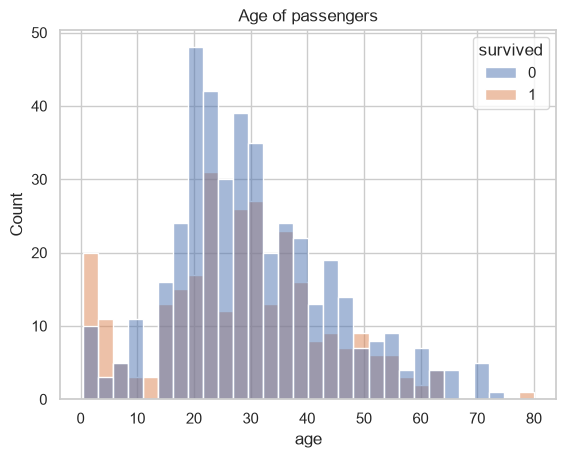

In [10]:
sns.histplot(data=df, x="age", bins=30, hue = "survived")
plt.title("Age of passengers")
plt.show()

# hue="survived"

There is a very tall bar at 28. That is because we filled 177 missing ages with the median (28). This is a side effect of cleaning. It is good to know.

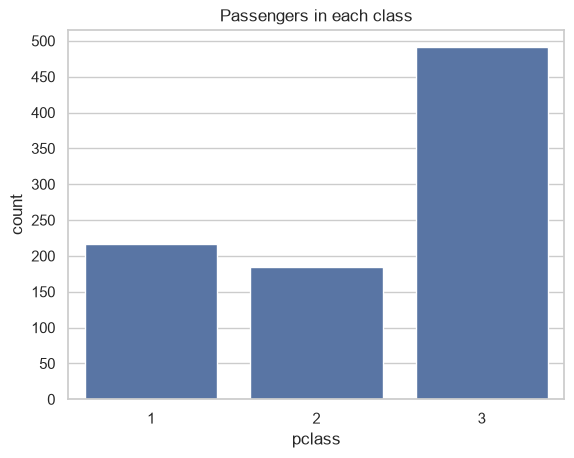

In [ ]:
sns.countplot(data=df, x="pclass")
plt.yticks(range(0, 501, 50))
plt.title("Passengers in each class")
plt.show()

### ✏️ QUICK CHECK 4: Distribution

Draw a histogram of `fare` with `bins=40`. Add a title.

Most tickets are cheap or expensive? Do you see a few very high fares far to the right?

Write your code in the cell below.

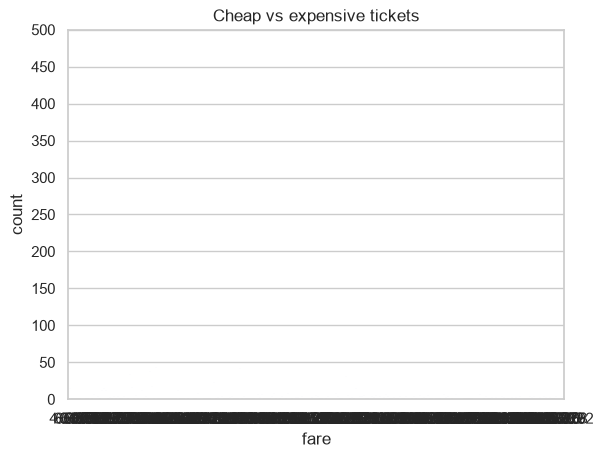

In [13]:
sns.countplot(data=df, x="fare")
plt.yticks(range(0, 501, 50))
plt.title("Cheap vs expensive tickets")
plt.show()

## CONCEPT: Step 4b: Find outliers

### 1. What is an outlier?

An **outlier** is a value that is **very far** from the other values.

**Example:** the monthly pocket money of 9 students in a class (in Rs):

```
500   600   700   700   800   900   1000   1200   8000
```

8 students get between Rs 500 and Rs 1200. One student gets **Rs 8000**. That student is an **outlier**.

### 2. Why do we need to find outliers?

**Reason 1: outliers can give a wrong picture.**

- The **average** pocket money of the 9 students = **Rs 1600**.
- But 8 of the 9 students get **less** than Rs 1600! The average doesn't describe the class well.
- Without the Rs 8000 student, the average is **Rs 800**. One student **doubled** the average.
- Later, AI models learn from averages too. Outliers can confuse them in the same way.

**Reason 2: an outlier can be a mistake.**
- Someone typed `8000` but meant `800` (one extra zero).
- Age = 250 years, or a price of -500. These are impossible values. We must **fix or remove** them.

**Reason 3: an outlier can be the most interesting thing in the data.**
- A bank looks for very large unusual payments to catch **fraud**.
- A shop looks for a customer who buys 100 times more than others. Maybe it's a business customer.

So we **find** outliers first, then **look** at them, and then **decide** what to do.

### 3. How do we decide what is "very far"?

"Very far" needs a **rule**, so everyone gets the same answer. We can't use the average, because the outlier itself pulls the average up. So we use the **middle of the data**, which outliers can't move. This is the **IQR rule**.

**Step 1: Sort the data and cut it into 4 equal parts.** The cut points are called **quartiles**.

```
500   600 | 700   700   800   900   1000 | 1200   8000
          ↑                          ↑
       Q1 = 700                  Q3 = 1000
```

- **Q1** = 700. 25% (a quarter) of the students get less than this.
- **Q3** = 1000. 75% (three quarters) get less than this.
- Between Q1 and Q3 are the **middle 50%** of the students. These are the "normal" values.

**Step 2: Find the IQR.**

**IQR** means **InterQuartile Range**: the distance **between the quartiles**.

```
IQR = Q3 - Q1 = 1000 - 700 = 300
```

It shows how wide the "normal" middle part is. The Rs 8000 student does **not** change the IQR. That is why we use it.

**Step 3: Build a fence on each side.**

We allow some extra space outside the middle: **1.5 × IQR** = 1.5 × 300 = **450**.

```
Lower fence = Q1 - 1.5 × IQR = 700 - 450  = 250
Upper fence = Q3 + 1.5 × IQR = 1000 + 450 = 1450
```

**Step 4: Anything outside the fences is an outlier.**

- Rs 8000 is **above 1450** → **outlier**. ✅
- Rs 1200 is inside the fence → normal.
- Nobody is below 250 → no low outliers.

```
   250                                          1450
    |----[ 700 ======== 1000 ]--------------------|                    o 8000
 lower fence      the box = IQR             upper fence             outlier
```

**Why 1.5?** It is a rule from **John Tukey**, the statistician who also invented the box plot. It is not a law of maths. It just works well: it catches values that are really unusual, but not normal values.

### 4. The box plot uses the same rule

- The **box** = from Q1 to Q3 (the IQR).
- The **lines** (whiskers) go up to the fences.
- The **dots** = the outliers outside the fences.

So when you draw `sns.boxplot`, Seaborn does these 4 steps for you.

### 5. Found an outlier? Now decide

| What is it? | Example | What to do |
|-------------|---------|------------|
| A **mistake** | age = 250, price = -500 | fix it, or remove the row |
| A **real** but rare value | a rich passenger with a very expensive ticket | **keep** it. It is real data |

**An outlier is not always a mistake!** Always look at it before you delete it.

Let's check our pocket money example with code:

In [ ]:
pocket = pd.Series([500, 600, 700, 700, 800, 900, 1000, 1200, 8000])

print("Average:", pocket.mean(), "  Median:", pocket.median())

q1 = pocket.quantile(0.25)
q3 = pocket.quantile(0.75)
iqr = q3 - q1
print("Q1:", q1, "  Q3:", q3, "  IQR:", iqr)

low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
print("Fences:", low, "to", high)

print("Outliers:", pocket[(pocket < low) | (pocket > high)].tolist())

### EXAMPLE: Outliers in fare

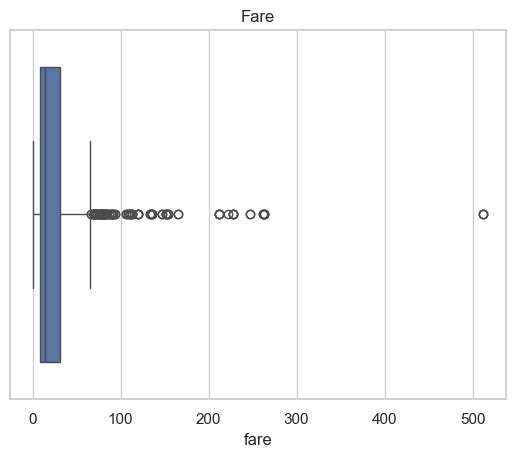

In [29]:
sns.boxplot(data=df, x="fare")
plt.title("Fare")
plt.show()

In [31]:
q1 = df["fare"].quantile(0.25)
q3 = df["fare"].quantile(0.75)
iqr = q3 - q1
high = q3 + 1.5 * iqr

print("Q1:", q1, " Q3:", q3, " IQR:", round(iqr, 1))
print("Above", round(high, 1), "is an outlier")

outliers = df[df["fare"] > high]
print("Number of outliers:", len(outliers))
outliers.sort_values("fare", ascending=False).head()

Q1: 7.9104  Q3: 31.0  IQR: 23.1
Above 65.6 is an outlier
Number of outliers: 116


,survived,pclass,gender,age,sibsp,parch,fare,embarked,alone,family_size,age_group,is_female
679,1,1,male,36.0,0,1,512.3292,C,False,2,Adult,0
258,1,1,female,35.0,0,0,512.3292,C,True,1,Adult,1
737,1,1,male,35.0,0,0,512.3292,C,True,1,Adult,0
341,1,1,female,24.0,3,2,263.0000,S,False,6,Adult,1
438,0,1,male,64.0,1,4,263.0000,S,False,6,Adult,0


116 passengers have a very high fare. Most of them are in **first class**. These are real rich passengers, not mistakes. So we **keep** them.

### ✏️ QUICK CHECK 5: Outliers

Use the IQR rule on the `age` column. Find the low limit and the high limit.

How many passengers are outliers? Who are they: very young, very old, or both? Are they mistakes?

Write your code in the cell below.

In [ ]:
# Write your code here

## CONCEPT: Step 4c: Find relations

- Use the correlation heatmap from Class 16.
- We only need the row for `survived`: `df.corr(numeric_only=True)["survived"]`.
- Remember: the size of the number shows how strong the relation is. The sign (+ or -) shows the direction.

### EXAMPLE: What is related to survival?

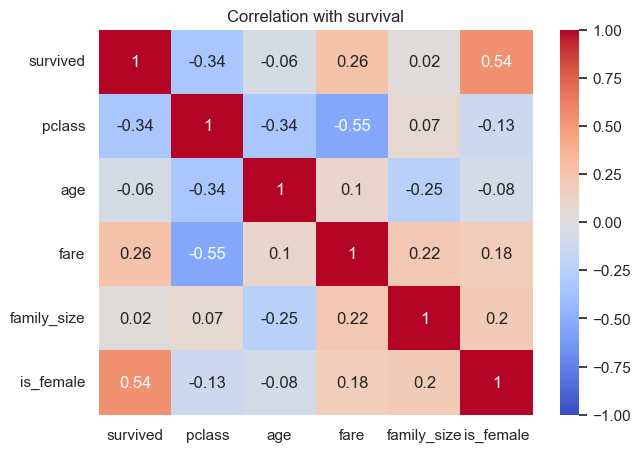

In [32]:
cols = ["survived", "pclass", "age", "fare", "family_size", "is_female"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[cols].corr().round(2), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation with survival")
plt.show()

### ✏️ QUICK CHECK 6: Relations

Print the correlation of every column in `cols` with `survived`, sorted from low to high.

Which column is the **most** related to survival? Is `pclass` positive or negative? What does that mean in words?

Write your code in the cell below.

In [ ]:
# Write your code here

# Hour 3: Show the Findings and Write Conclusions

## CONCEPT: Survival rate of a group

- `survived` is 1 or 0. So the **mean** of `survived` = the **part of people who survived**.
- Example: the mean is 0.74 → 74% survived.
- `df.groupby("gender")["survived"].mean()` = survival rate for men and for women.
- `sns.barplot(data=df, x="gender", y="survived")` draws this for you.

### EXAMPLE: Question 1 and 2: Overall, and men vs women

In [ ]:
print("Overall survival rate:", round(df["survived"].mean() * 100), "%")
print(df.groupby("gender")["survived"].mean().round(2))

In [ ]:
sns.barplot(data=df, x="gender", y="survived", errorbar=None)
plt.title("Survival rate: men vs women")
plt.ylabel("Survival rate (0 to 1)")
plt.savefig("survival_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()

### EXAMPLE: Question 3: Did ticket class matter? (with `hue`)

In [ ]:
print(df.groupby("pclass")["survived"].mean().round(2))

sns.barplot(data=df, x="pclass", y="survived", hue="gender", errorbar=None)
plt.title("Survival rate by class and gender")
plt.ylabel("Survival rate (0 to 1)")
plt.savefig("survival_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

### ✏️ QUICK CHECK 7: Children vs adults

Answer **Question 4**: Did children survive more than adults?
Print the survival rate for each `age_group`, and draw a bar chart. Save it as `survival_by_age.png`.

Write your code in the cell below.

In [ ]:
# Write your code here

### ✏️ QUICK CHECK 8: Practice (Harder)

1) Find the survival rate for each `embarked` city. Which city had the highest survival rate?
2) Draw a bar chart of the survival rate by `family_size`. Were people alone (`family_size` = 1) more or less likely to survive than small families (2 to 4)?
3) **Think:** About half of the passengers from C (Cherbourg) were in first class. Can that explain the result in part 1? (Hint: `pd.crosstab(df["embarked"], df["pclass"])` counts each pair.)

Write your code in the cell below.

In [ ]:
# Write your code here

## CONCEPT: Step 5: Write conclusions

A good finding has **3 parts**: what you found + a **number** + what it **means**.

- Weak: "Women survived more."
- Good: "**74%** of women survived, but only **19%** of men. Women were about **4 times** more likely to survive. The rule on the ship was *women and children first*."

Every finding should have **one chart** that shows it.

## Our findings: Titanic

1. **Overall:** only **38%** of passengers survived.
2. **Gender:** **74%** of women survived, but only **19%** of men. This is the strongest relation in the data (correlation **0.54**).
3. **Class:** **63%** of first class survived, **47%** of second class and only **24%** of third class. Money and class mattered.
4. **Age:** **59%** of children (under 16) survived, but only **36%** of adults.
5. **Cleaning note:** `age` was missing for 177 people. We filled it with the median (28). This makes the age results a little less exact.

**Answer to the big question:** The people most likely to survive were **women and children in first and second class**. Men in third class were the least likely.

# Your Month 1 Portfolio Project

Now do **all 5 steps** on a new dataset, alone. Choose **one**. The files are in the same folder as this notebook (`Day 17`):

| Dataset | Load it | What is in it | A question to start |
|---------|---------|---------------|---------------------|
| **Tips** | `pd.read_csv("tips.csv")` | 244 restaurant bills and tips | Who gives bigger tips? |
| **Penguins** | `pd.read_csv("penguins.csv")` | 344 penguins: size and weight | How are the 3 types different? |
| **Diamonds** | `pd.read_csv("diamonds.csv")` | 53,940 diamonds and their price | What makes a diamond expensive? |

**What the columns mean:**

- **Tips:** `total_bill` (bill in dollars), `tip`, `sex` (of the person who paid), `smoker` (Yes/No), `day`, `time` (Lunch/Dinner), `size` (number of people at the table). No missing values.
- **Penguins:** `species` (3 types of penguin), `island` (where it lives), `bill_length_mm` and `bill_depth_mm` (size of the beak), `flipper_length_mm` (size of the wing), `body_mass_g` (weight in grams), `sex`. It has **19 missing values**, so you will practise cleaning.
- **Diamonds:** `carat` (weight), `cut` (quality of the cutting: Fair → Ideal), `color` (D = best → J), `clarity` (how clean inside: I1 = worst → IF = best), `price` (in dollars), `x`, `y`, `z` (length, width, depth in mm), `depth` and `table` (shape measurements in %). Big dataset: charts can be slow.

**Tip:** Tips and Penguins have a `sex` column. You can rename it to `gender`, like we did with Titanic: `df = df.rename(columns={"sex": "gender"})`.

**On Colab?** Upload the CSV file first (the folder icon on the left → upload). Or load it from the internet with `sns.load_dataset("tips")`.

You can also use your own dataset (for example from Kaggle). Ask the teacher first.

**What you must make:** a new notebook with these headings:

1. **Introduction:** what the data is, and your **3 to 5 questions**
2. **Load and inspect:** `shape`, `info`, `describe`, missing values
3. **Clean:** each fix, with one line on **why**
4. **Explore:** at least 1 histogram, 1 box plot (outliers) and 1 heatmap (relations)
5. **Findings:** 3 or more findings, each with a **number** and a **saved chart**
6. **Conclusion:** answer your questions in 3 to 5 lines

**Present it:** 5 minutes, 3 findings, 1 chart for each. Then put it on GitHub. It is your first portfolio piece.

# Home Practice: Interview-Style Questions

1. What is EDA? Why do we do it before building a model?
2. What are the 5 steps of EDA?
3. A column has 70% missing values. What would you do? And if it has 2% missing?
4. Why do we fill missing ages with the **median** and not the **mean**?
5. What is an outlier? Should we always delete outliers? Give an example.
6. What does the mean of a 0/1 column tell you?
7. Write one finding about the Titanic in the "good" style: finding + number + meaning.

# Key Takeaways

- **EDA** = understand the data **before** building a model.
- 5 steps: **Load → Inspect → Clean → Explore → Conclude**.
- Start with **questions**, not with charts.
- Every cleaning step needs a **reason** (drop, fill with median, fill with mode).
- An **outlier** is not always a mistake. Check it first.
- The mean of a 0/1 column = a **rate** (like a survival rate).
- A good finding = **what** + **number** + **meaning**, with one chart.

**Next month:** Machine Learning. We will teach a computer to **predict** answers from data like this.